# Run artworks example

This notebook implements a quick inference on the labeled examples. Since the examples source code are now stored in a JSON file, and not into seperate files, we have this notebook to not interfeer with he code that will be used to run on the new source code files.

## Imports, configs and read data

In [6]:
import json
import yaml
from Model import LLM_Model
from Prompts import *
from collections import Counter
import matplotlib.pyplot as plt

def get_prompt_template(prompt_version):
    return globals()[prompt_version].template

def count_labels(examples, classification_key):
    counter = Counter()

    for ex in examples:
        classification = ex.get(classification_key, {})

        for dimension, labels in classification.items():
            for label in labels:
                counter[f"{dimension}_{label}"] += 1

    return dict(counter)


def count_all_labels(examples):
    return {
        "classification": count_labels(examples, "classification"),
        "predicted_classification": count_labels(examples, "predicted_classification"),
    }

def count_labels(examples, classification_key):
    counter = Counter()

    for ex in examples:
        classification = ex.get(classification_key, {})
        for dimension, labels in classification.items():
            for label in labels:
                counter[f"{dimension}_{label}"] += 1

    return counter


def plot_all_distributions(examples):
    true_counts = count_labels(examples, "classification")
    pred_counts = count_labels(examples, "predicted_classification")

    all_labels = sorted(set(true_counts) | set(pred_counts))
    x = range(len(all_labels))
    width = 0.4

    plt.figure(figsize=(12, 5))
    plt.bar([i - width/2 for i in x], [true_counts.get(label, 0) for label in all_labels], width=width, label="classification")
    plt.bar([i + width/2 for i in x], [pred_counts.get(label, 0) for label in all_labels], width=width, label="predicted_classification")

    plt.xticks(x, all_labels, rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title("Classification vs Predicted Classification")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_distributions_by_dimension(examples):
    true_counts = count_labels(examples, "classification")
    pred_counts = count_labels(examples, "predicted_classification")

    for dimension in ["entities", "interaction", "outcome"]:
        labels = sorted([
            key.split("_", 1)[1]
            for key in set(true_counts) | set(pred_counts)
            if key.startswith(f"{dimension}_")
        ])

        x = range(len(labels))
        width = 0.4

        plt.figure(figsize=(8, 4)) 
        plt.bar([i - width/2 for i in x], [true_counts.get(f"{dimension}_{label}", 0) for label in labels], width=width, label="classification")
        plt.bar([i + width/2 for i in x], [pred_counts.get(f"{dimension}_{label}", 0) for label in labels], width=width, label="predicted_classification")

        plt.xticks(x, labels, rotation=45, ha="right")
        plt.ylabel("Count")
        plt.title(f"{dimension}: classification vs predicted")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [7]:
# Read configs
print("Configs...")
with open("../config.yml", "r") as f:
    configs = yaml.safe_load(f)

config_mode = configs["chosen_config"]['config_mode']
model = configs["chosen_config"]["model"]

Configs...


In [8]:
# Read examples
with open("../examples/artworks_corrected_classif.json") as f:
    examples = json.load(f)

# Print one examples
# examples[0]

In [9]:
llm_model = LLM_Model(
    model_name=configs[model]['model_name'],
    base_url=configs[model]['base_url'],
    system_prompt=configs[model]['system_prompt']
)

## Inference

In [10]:
prompt_version = "PROMPT_10c"
prompt = get_prompt_template(prompt_version)

print("Using this prompt:\n", prompt)

for i, artwork in enumerate(examples):
    # Read src code
    art_src_code = artwork['metadata']['content']

    # Pass it to LLM
    predicted_labels = llm_model.get_labels(
        prompt_template=prompt, 
        art_src_code=art_src_code, 
        system_prompt=llm_model.system_prompt
    )
    if isinstance(predicted_labels.get("interaction"), str):
        predicted_labels["interaction"] = [predicted_labels["interaction"]]
    # print("Actual labels:", artwork['classification'])
    # print("Predicted labels:", predicted_labels)

    # Add prediction back to the json
    examples[i]["predicted_classification"] = predicted_labels
    

Using this prompt:
 You classify p5.js source code and return ONLY a JSON object.

Output format:
{"entities":[],"interaction":[],"outcome":[]}

Rules for output:
- Return valid JSON only.
- No markdown.
- No explanation.
- No extra text before or after the JSON.
- entities: array of 1+ tags when the sketch has any visible or audible output; use [] only if there is truly no perceptible artwork output
- interaction: array with exactly 1 tag, either "yes" or "no"
- outcome: array with 1+ modality tags and exactly 1 time tag
- If "auditory" is present, "time_based" must also be present

The ONLY allowed tags for each category are:

entities:
- "processed_audio"
- "processed_image"
- "processed_text"
- "synthesized_sound"
- "synthesized_image"
- "synthesized_text"
- "randomness"

interaction:
- "yes"
- "no"

outcome:
- "visual"
- "auditory"
- "static"
- "time_based"

How to classify

entities
- processed_audio: uses preexisting audio material or live audio input
  Examples: loadSound(), au

## Data Viz

In [11]:
results = count_all_labels(examples)

results["classification"]
results["predicted_classification"]

Counter({'outcome_visual': 74,
         'entities_synthesized_image': 73,
         'outcome_time_based': 64,
         'entities_randomness': 61,
         'interaction_no': 49,
         'interaction_yes': 25,
         'outcome_auditory': 10,
         'outcome_static': 10,
         'entities_processed_image': 10,
         'entities_processed_audio': 7,
         'entities_synthesized_sound': 4,
         'entities_synthesized_text': 4,
         'entities_processed_text': 2})

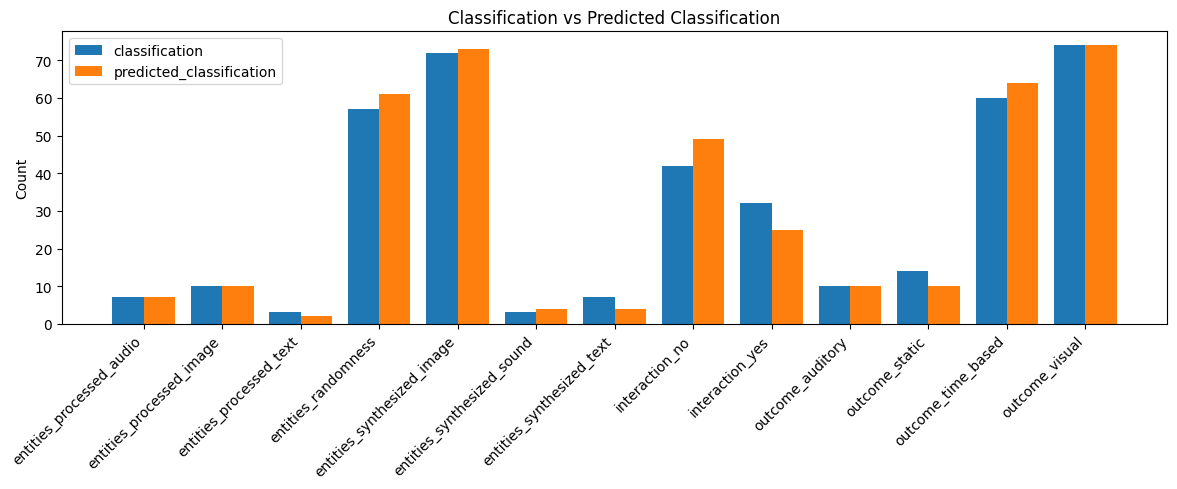

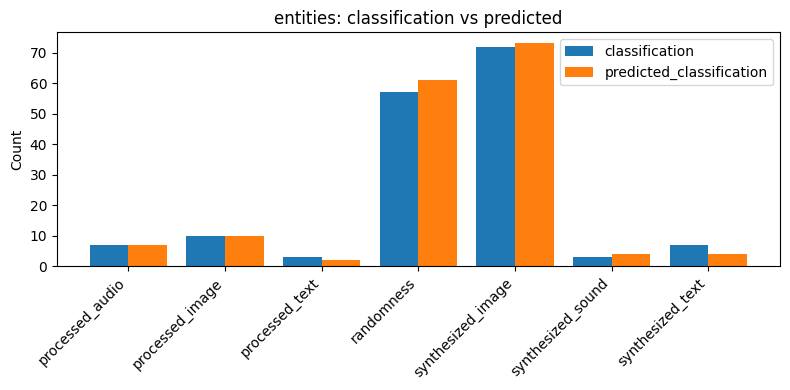

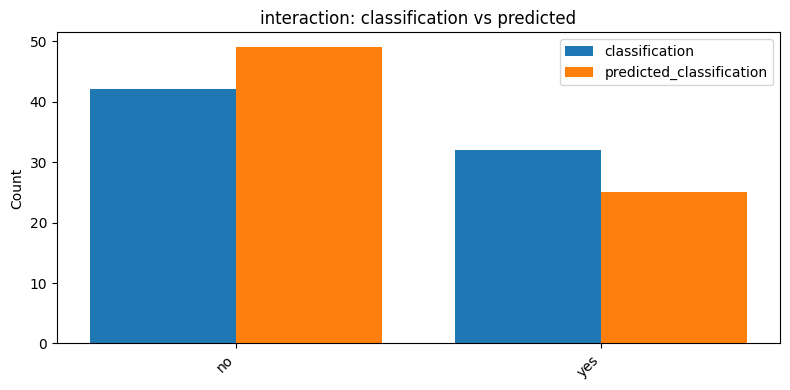

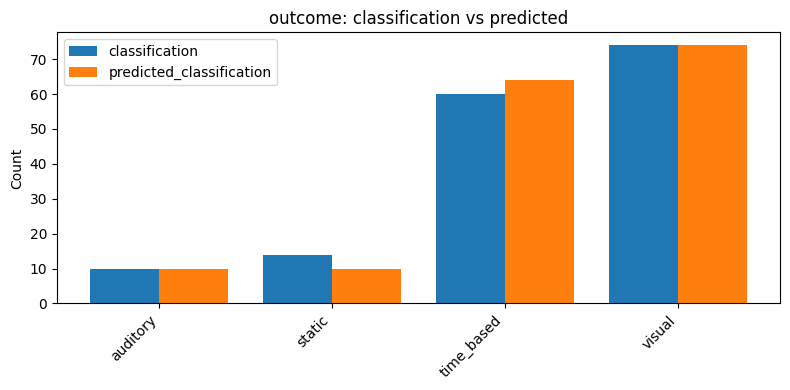

In [12]:
plot_all_distributions(examples)
plot_distributions_by_dimension(examples)

In [13]:
examples


[{'id': 'A1',
  'title': 'black&white_rotate',
  'artist': 'Benoit Baudry',
  'repoUrl': 'None',
  'year': '2020',
  'classification': {'entities': ['synthesized_image', 'randomness'],
   'interaction': ['no'],
   'outcome': ['visual', 'time_based']},
  'description': 'A generative landscape created using Perlin noise.',
  'llm_notes': 'Relies on Perlin noise to produce smooth organic shapes resembling a landscape.',
  'metadata': {'file_name': 'black&white_rotate',
   'extension': '.js',
   'content': 'let canvasWidth = 800;\nlet canvasHeight = 800;\nlet topLayer;\nlet bottomLayer;\nlet startX = -canvasWidth; // Start off-screen\nlet weightDifference;\nlet blackWeight;\nlet whiteWeight;\nlet maskGraphics; \n\n\nfunction setup() {\n  createCanvas(canvasWidth, canvasHeight);\n\n  topLayer = createGraphics(canvasWidth, canvasHeight); \n  bottomLayer = createGraphics(canvasWidth, canvasHeight); \n\n  weightDifference = random(-5, 5);\n  blackWeight = random(5, 20);\n  whiteWeight = blackW

In [14]:
def get_mismatches(data):
    entries = data.values() if isinstance(data, dict) else data

    def normalize(cls):
        return {k: sorted(v) for k, v in cls.items()}

    return [
        item for item in entries
        if normalize(item["classification"]) != normalize(item["predicted_classification"])
    ]
mismatches = get_mismatches(examples)

print(len(mismatches))
mismatches

25


[{'id': 'A4',
  'title': 'sound003',
  'artist': 'Benoit Baudry',
  'repoUrl': 'None',
  'year': '2020',
  'classification': {'entities': ['synthesized_sound', 'synthesized_image'],
   'interaction': ['yes'],
   'outcome': ['auditory', 'visual', 'time_based']},
  'description': 'A generative landscape created using Perlin noise.',
  'llm_notes': 'Relies on Perlin noise to produce smooth organic shapes resembling a landscape.',
  'metadata': {'file_name': 'sound003',
   'extension': '.html',
   'content': '<!DOCTYPE html>\n<html lang="en">\n<html>\n\n<head>\n    <meta charset="UTF-8">\n    <script src="https://cdn.jsdelivr.net/npm/p5@1.6.0/lib/p5.min.js"></script>\n    <script src="https://cdn.jsdelivr.net/npm/tone@14.7.77/build/Tone.min.js"></script>\n    <script src="libraries/StartAudioContext.js"></script>\n    <style>\n        body {\n            padding: 0;\n            margin: 0;\n        }\n    </style>\n</head>\n\n<body>\n    <script>\n        let canvas;\n        var w = docum